In [60]:
import pandas as pd   
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from tabulate import tabulate


import warnings
warnings.filterwarnings('ignore')


In [2]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 500)

In [26]:
data = pd.read_json(path_or_buf='menu.jsonl', lines=True)

#### Добавляем солбцы с калориями и разделяем бжу

In [27]:
kbju_df = pd.DataFrame(data['kbju'].tolist())

# Объединяем с исходным DataFrame
data = pd.concat([data, kbju_df], axis=1)

In [28]:
data[:5]

,id,url,page,title,description,dish_image,kbju,ready_in,kitchen_time,cuisine,common_allergens,ingredients,recipe,calories,protein,fat,carbs
0,267099,https://food.ru/recipes/267099-zakusochnye-kek...,1,Закусочные кексы из замороженных овощей,Тесто для этих кексов не нужно долго замешиват...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 118.19, 'protein': 6.51, 'fat': 4...",55 минут,20 минут,европейская,"[Белок коровьего молока, Злаки, содержащие глю...","[Замороженная смесь «8 овощей» 400 г, Кефир 2,...",### подготовиться\n![подготовиться](https://cd...,118.19,6.51,4.24,13.10
1,267097,https://food.ru/recipes/267097-tosty-s-konserv...,1,Сэндвичи с консервированым лососем,"В этом рецепте объединились и европейские, и а...",https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 203.11, 'protein': 10.37, 'fat': ...",15 минут,15 минут,европейская,"[Злаки, содержащие глютен, Рыба, Сельдерей, Со...","[Хлеб цельнозерновой 200 г, Майонез 3 ст. л. =...",### подготовиться\n![подготовиться](https://cd...,203.11,10.37,12.41,11.59
2,266791,https://food.ru/recipes/266791-zavtrak-s-fasol...,1,Завтрак с фасолью и яйцами,Блюдо для завтрака с мексиканским характером: ...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 150.57, 'protein': 6.28, 'fat': 8...",40 минут,25 минут,мексиканская,"[Пищевые добавки, Яйцо]","[Консервированная белая фасоль 400 г, Яйца 2 ш...",### подготовиться\n![подготовиться](https://cd...,150.57,6.28,8.33,14.78
3,267017,https://food.ru/recipes/267017-muss-i-semgi,1,Мусс из семги,Мусс из семги готовится за 5 минут: все ингред...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 216.44, 'protein': 19.69, 'fat': ...",5 минут,5 минут,авторская,"[Белок коровьего молока, Рыба]","[Слабосоленая форель 200 г, Сливочный сыр 150 ...",### подготовиться\n![подготовиться](https://cd...,216.44,19.69,14.09,1.35
4,266742,https://food.ru/recipes/266742-ovsjanka-s-imbi...,1,"Овсянка с имбирем, грушей и медом",Горячая каша с ароматом имбиря и карамелизиров...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 86.83, 'protein': 1.98, 'fat': 1....",15 минут,15 минут,авторская,"[Злаки, содержащие глютен]","[Овсяные хлопья 0,5 стакан = 40 г, Вода 1 стак...",### подготовиться\n![подготовиться](https://cd...,86.83,1.98,1.83,15.42


### Общая информация о данных

In [29]:
print("="*50)
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)

print("\n1.1 Структура данных:")
print(data.info())

print("\n1.2 Статистика числовых признаков:")
print(data[['calories', 'protein', 'fat', 'carbs']].describe())

print("\n1.3 Пропущенные значения:")
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
print(missing_df[missing_df['Пропущено'] > 0])

# 1.4 Преобразуем столбцы со списками/словарями
def safe_literal_eval(val):
    """Безопасное преобразование строк в списки/словари"""
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return val
    return val

# Преобразуем нужные столбцы
list_columns = ['common_allergens', 'ingredients']
for col in list_columns:
    if col in data.columns:
        data[col] = data[col].apply(safe_literal_eval)

# 1.5 Анализ уникальности
print("\n1.4 Уникальность значений:")
print(f"Уникальных рецептов: {data['id'].nunique()}")
print(f"Уникальных заголовков: {data['title'].nunique()}")
print(f"Уникальных URL: {data['url'].nunique()}")

# Проверка дубликатов
duplicates = data.duplicated(subset=['id', 'title'], keep=False).sum()
print(f"Возможных дубликатов: {duplicates}")

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ

1.1 Структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2500 non-null   int64  
 1   url               2500 non-null   object 
 2   page              2500 non-null   int64  
 3   title             2500 non-null   object 
 4   description       2500 non-null   object 
 5   dish_image        2500 non-null   object 
 6   kbju              2500 non-null   object 
 7   ready_in          2500 non-null   object 
 8   kitchen_time      2500 non-null   object 
 9   cuisine           2500 non-null   object 
 10  common_allergens  2500 non-null   object 
 11  ingredients       2500 non-null   object 
 12  recipe            2500 non-null   object 
 13  calories          2500 non-null   float64
 14  protein           2500 non-null   float64
 15  fat               2500 non-null   flo

In [30]:
data[data[['id']].duplicated()]

,id,url,page,title,description,dish_image,kbju,ready_in,kitchen_time,cuisine,common_allergens,ingredients,recipe,calories,protein,fat,carbs


In [31]:
data[data[['url']].duplicated()]

,id,url,page,title,description,dish_image,kbju,ready_in,kitchen_time,cuisine,common_allergens,ingredients,recipe,calories,protein,fat,carbs


Видно, что значения уникальные, пропусков нет, id уникальные, url уникальные   
Всего данных не так много - 2500 записей

### Распределения полезные

Далее хочется посмотреть на распределение по калориям, белкам, жирам, углеводам   
В первую очередь хочется понять, если ли в данных объекты с небольшим кол-вом калорий и других составляющих, нет ли каких-то неожиданных перекосов.  
Для этого лучше всего подойдет - гистограмма


2. АНАЛИЗ ПИТАТЕЛЬНОЙ ЦЕННОСТИ


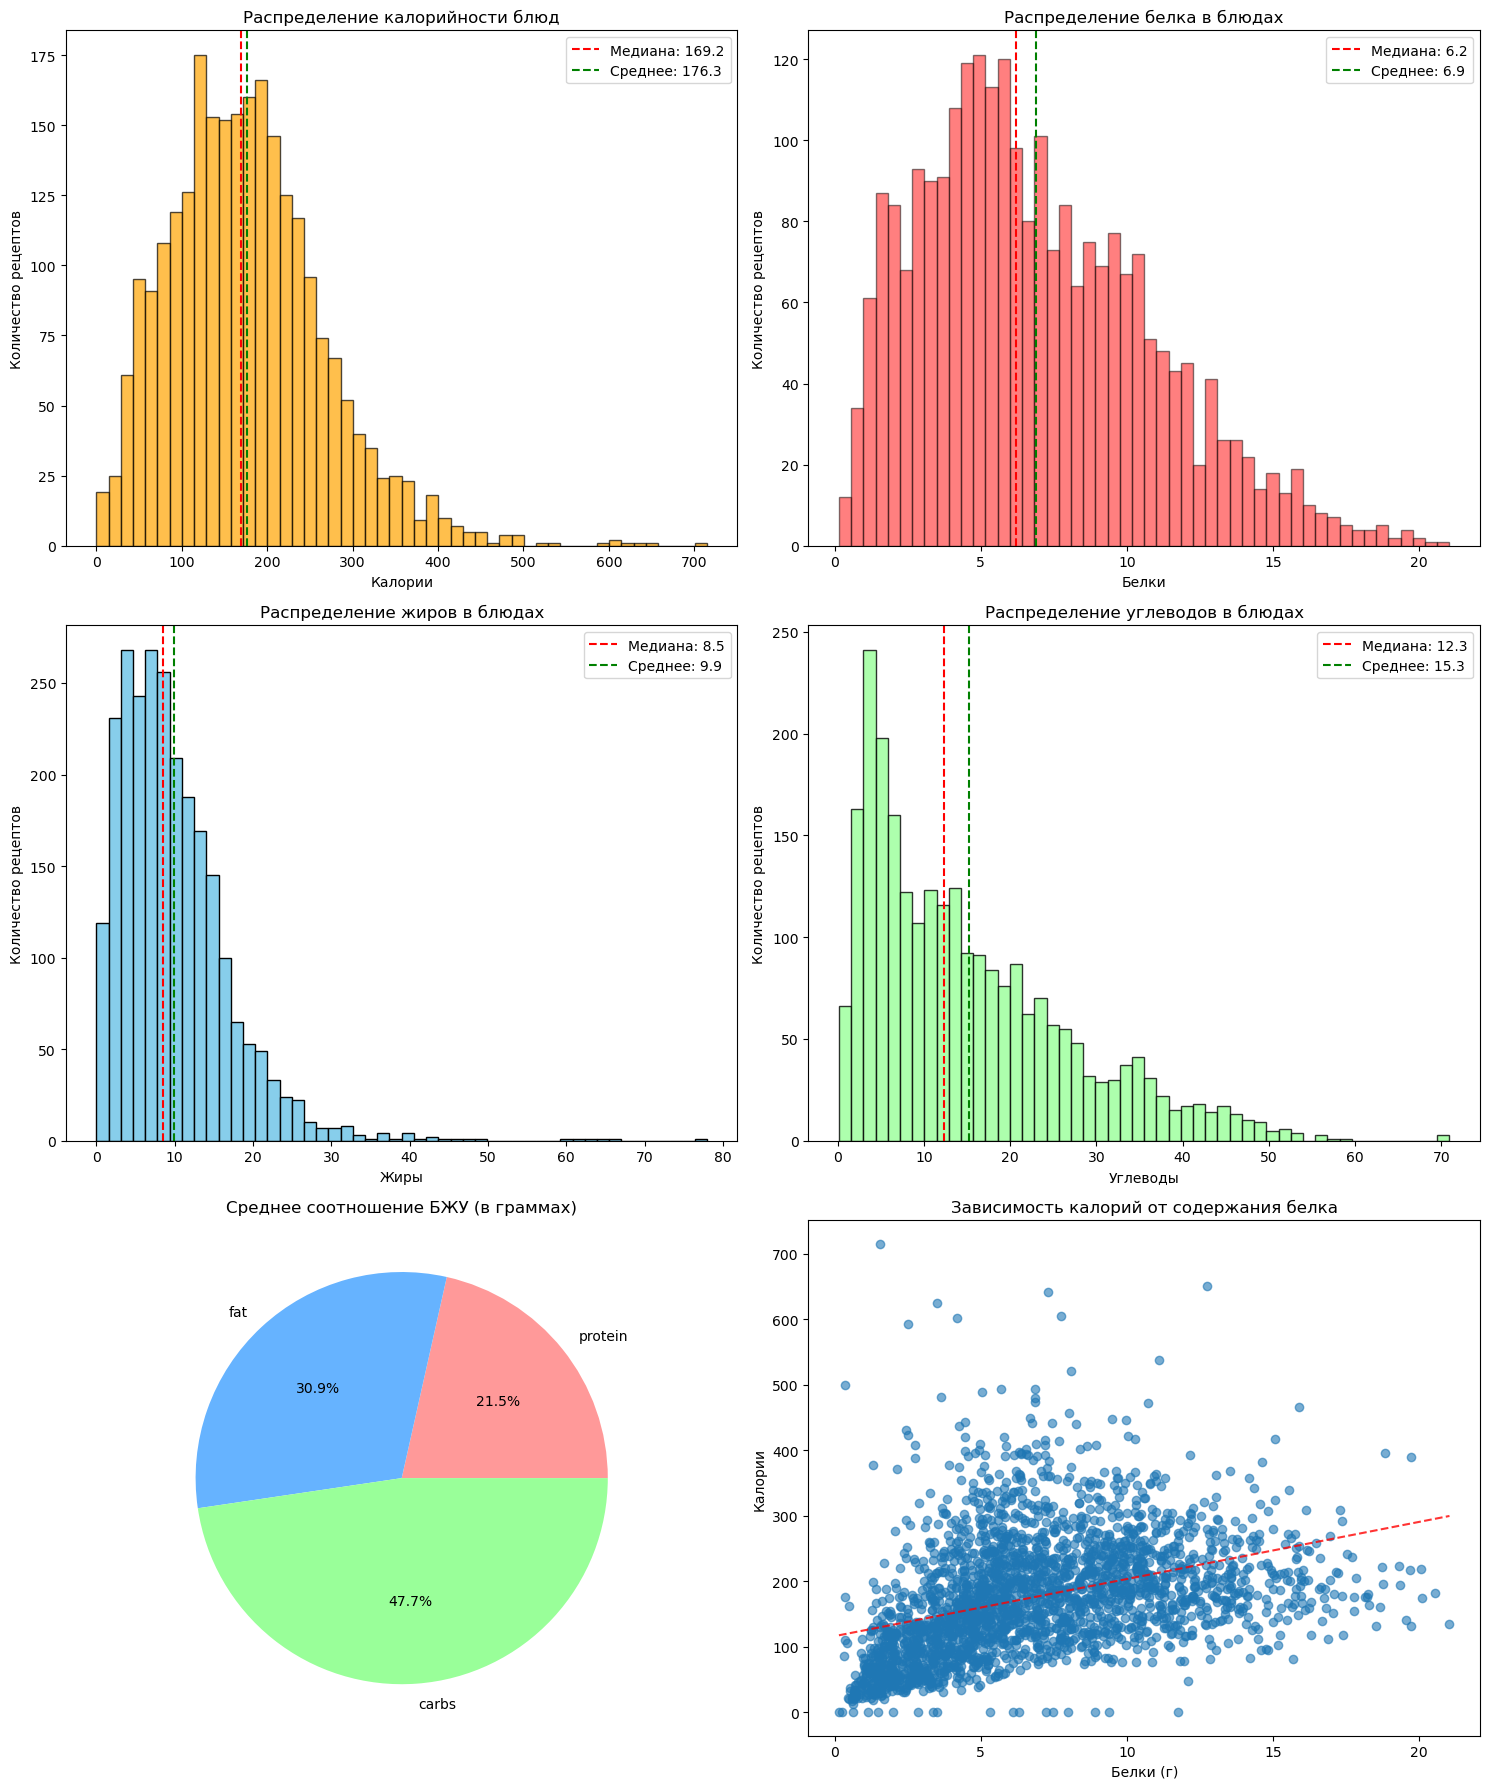


2.1 Категории блюд по калорийности:
calorie_category
Очень низкая     1024
Низкая           1238
Средняя           201
Высокая            13
Очень высокая       6
Name: count, dtype: int64


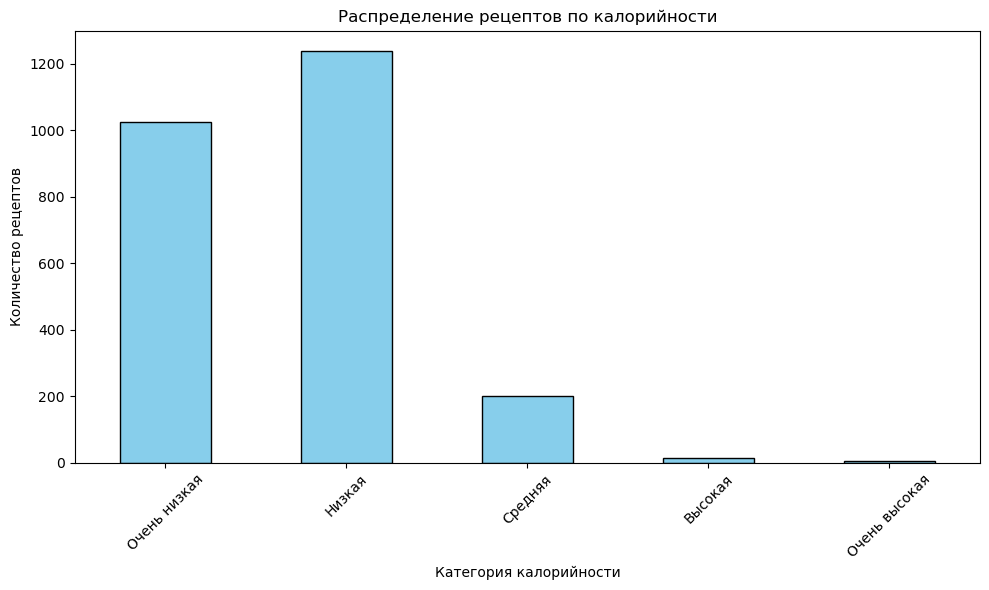

In [40]:
# 2.1 Анализ калорийности
print("\n" + "="*50)
print("2. АНАЛИЗ ПИТАТЕЛЬНОЙ ЦЕННОСТИ")
print("="*50)

# Гистограмма распределения калорий
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Распределение калорий
axes[0,0].hist(data['calories'].dropna(), bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[0,0].set_xlabel('Калории')
axes[0,0].set_ylabel('Количество рецептов')
axes[0,0].set_title('Распределение калорийности блюд')
axes[0,0].axvline(data['calories'].median(), color='red', linestyle='--', 
                  label=f'Медиана: {data["calories"].median():.1f}')
axes[0,0].axvline(data['calories'].mean(), color='green', linestyle='--', 
                  label=f'Среднее: {data["calories"].mean():.1f}')
axes[0,0].legend()

# Распределение белков
axes[0,1].hist(data['protein'].dropna(), bins=50, edgecolor='black', color='red', alpha=0.5)
axes[0,1].set_xlabel('Белки')
axes[0,1].set_ylabel('Количество рецептов')
axes[0,1].set_title('Распределение белка в блюдах')
axes[0,1].axvline(data['protein'].median(), color='red', linestyle='--', 
                  label=f'Медиана: {data["protein"].median():.1f}')
axes[0,1].axvline(data['protein'].mean(), color='green', linestyle='--', 
                  label=f'Среднее: {data["protein"].mean():.1f}')
axes[0,1].legend()  

# Распределение жиров
axes[1,0].hist(data['fat'].dropna(), bins=50, edgecolor='black', color='skyblue', alpha=1)
axes[1,0].set_xlabel('Жиры')
axes[1,0].set_ylabel('Количество рецептов')
axes[1,0].set_title('Распределение жиров в блюдах')
axes[1,0].axvline(data['fat'].median(), color='red', linestyle='--', 
                  label=f'Медиана: {data["fat"].median():.1f}')
axes[1,0].axvline(data['fat'].mean(), color='green', linestyle='--', 
                  label=f'Среднее: {data["fat"].mean():.1f}')
axes[1,0].legend() 

# Распределение углеводов
axes[1,1].hist(data['carbs'].dropna(), bins=50, edgecolor='black', color='#99ff99', alpha=0.8)
axes[1,1].set_xlabel('Углеводы')
axes[1,1].set_ylabel('Количество рецептов')
axes[1,1].set_title('Распределение углеводов в блюдах')
axes[1,1].axvline(data['carbs'].median(), color='red', linestyle='--', 
                  label=f'Медиана: {data["carbs"].median():.1f}')
axes[1,1].axvline(data['carbs'].mean(), color='green', linestyle='--', 
                  label=f'Среднее: {data["carbs"].mean():.1f}')
axes[1,1].legend() 


# Соотношение БЖУ
nutrients = ['protein', 'fat', 'carbs']
colors = ['#ff9999', '#66b3ff', '#99ff99']
avg_nutrients = data[nutrients].mean()

axes[2,0].pie(avg_nutrients, labels=nutrients, colors=colors, autopct='%1.1f%%')
axes[2,0].set_title('Среднее соотношение БЖУ (в граммах)')

# Калории vs Белки
axes[2,1].scatter(data['protein'], data['calories'], alpha=0.6)
axes[2,1].set_xlabel('Белки (г)')
axes[2,1].set_ylabel('Калории')
axes[2,1].set_title('Зависимость калорий от содержания белка')
z = np.polyfit(data['protein'].dropna(), data['calories'].dropna(), 1)
p = np.poly1d(z)
axes[2,1].plot(data['protein'].sort_values(), p(data['protein'].sort_values()), 
               "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# 2.2 Анализ по категориям калорийности
print("\n2.1 Категории блюд по калорийности:")
data['calorie_category'] = pd.cut(data['calories'], 
                                  bins=[0, 150, 300, 450, 600, float('inf')],
                                  labels=['Очень низкая', 'Низкая', 'Средняя', 
                                          'Высокая', 'Очень высокая'])

calorie_dist = data['calorie_category'].value_counts().sort_index()
print(calorie_dist)

fig, ax = plt.subplots(figsize=(10, 6))
calorie_dist.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_xlabel('Категория калорийности')
ax.set_ylabel('Количество рецептов')
ax.set_title('Распределение рецептов по калорийности')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Аллергены

In [5]:
# Предполагаем, что common_allergens уже список
all_allergens = []

# Собираем все аллергены из всех записей
for allergens_list in data['common_allergens'].dropna():
    if isinstance(allergens_list, list):
        # Добавляем все элементы списка, очищая от лишних пробелов
        all_allergens.extend([str(item).strip() for item in allergens_list])

# Получаем уникальные значения
unique_allergens = sorted(set(all_allergens))

print(f"Всего уникальных аллергенов: {len(unique_allergens)}")
print("\nСписок уникальных аллергенов:")
for i, allergen in enumerate(unique_allergens, 1):
    print(f"{i:2}. {allergen}")

Всего уникальных аллергенов: 16

Список уникальных аллергенов:
 1. Арахис
 2. Белок коровьего молока
 3. Горчица
 4. Злаки
 5. Клубника
 6. Кунжут
 7. Моллюски
 8. Нет
 9. Орехи
10. Пищевые добавки
11. Ракообразные
12. Рыба
13. Сельдерей
14. Соя
15. Яйцо
16. содержащие глютен


Аллергенов не так много, **распарсим данные на столбцы с флагами**

In [44]:
allergen_dummies = data['common_allergens'].apply(
    lambda x: {allergen: 1 for allergen in x} if isinstance(x, list) else {}
)

allergen_df = pd.DataFrame(allergen_dummies.tolist()).fillna(0).astype(int)

# Объединяем с исходными данными
data = pd.concat([data, allergen_df], axis=1)
data.head(3)

,id,url,page,title,description,dish_image,kbju,ready_in,kitchen_time,cuisine,common_allergens,ingredients,recipe,calories,protein,fat,carbs,calorie_category,Белок коровьего молока,Злаки,содержащие глютен,Яйцо,Рыба,Сельдерей,Соя,Пищевые добавки,Горчица,Орехи,Клубника,Нет,Кунжут,Арахис,Ракообразные,Моллюски
0,267099,https://food.ru/recipes/267099-zakusochnye-kek...,1,Закусочные кексы из замороженных овощей,Тесто для этих кексов не нужно долго замешиват...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 118.19, 'protein': 6.51, 'fat': 4...",55 минут,20 минут,европейская,"[Белок коровьего молока, Злаки, содержащие глю...","[Замороженная смесь «8 овощей» 400 г, Кефир 2,...",### подготовиться\n![подготовиться](https://cd...,118.19,6.51,4.24,13.10,Очень низкая,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,267097,https://food.ru/recipes/267097-tosty-s-konserv...,1,Сэндвичи с консервированым лососем,"В этом рецепте объединились и европейские, и а...",https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 203.11, 'protein': 10.37, 'fat': ...",15 минут,15 минут,европейская,"[Злаки, содержащие глютен, Рыба, Сельдерей, Со...","[Хлеб цельнозерновой 200 г, Майонез 3 ст. л. =...",### подготовиться\n![подготовиться](https://cd...,203.11,10.37,12.41,11.59,Низкая,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0
2,266791,https://food.ru/recipes/266791-zavtrak-s-fasol...,1,Завтрак с фасолью и яйцами,Блюдо для завтрака с мексиканским характером: ...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 150.57, 'protein': 6.28, 'fat': 8...",40 минут,25 минут,мексиканская,"[Пищевые добавки, Яйцо]","[Консервированная белая фасоль 400 г, Яйца 2 ш...",### подготовиться\n![подготовиться](https://cd...,150.57,6.28,8.33,14.78,Низкая,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0



3. АНАЛИЗ РАСПРЕДЕЛЕНИЯ АЛЛЕРГЕНОВ
Найдено 15 аллергенов из 15
Аллергены для анализа: ['Белок коровьего молока', 'Злаки, содержащие глютен', 'Яйцо', 'Рыба', 'Сельдерей', 'Соя', 'Пищевые добавки', 'Горчица', 'Орехи', 'Клубника', 'Кунжут', 'Арахис', 'Ракообразные', 'Моллюски', 'Нет']


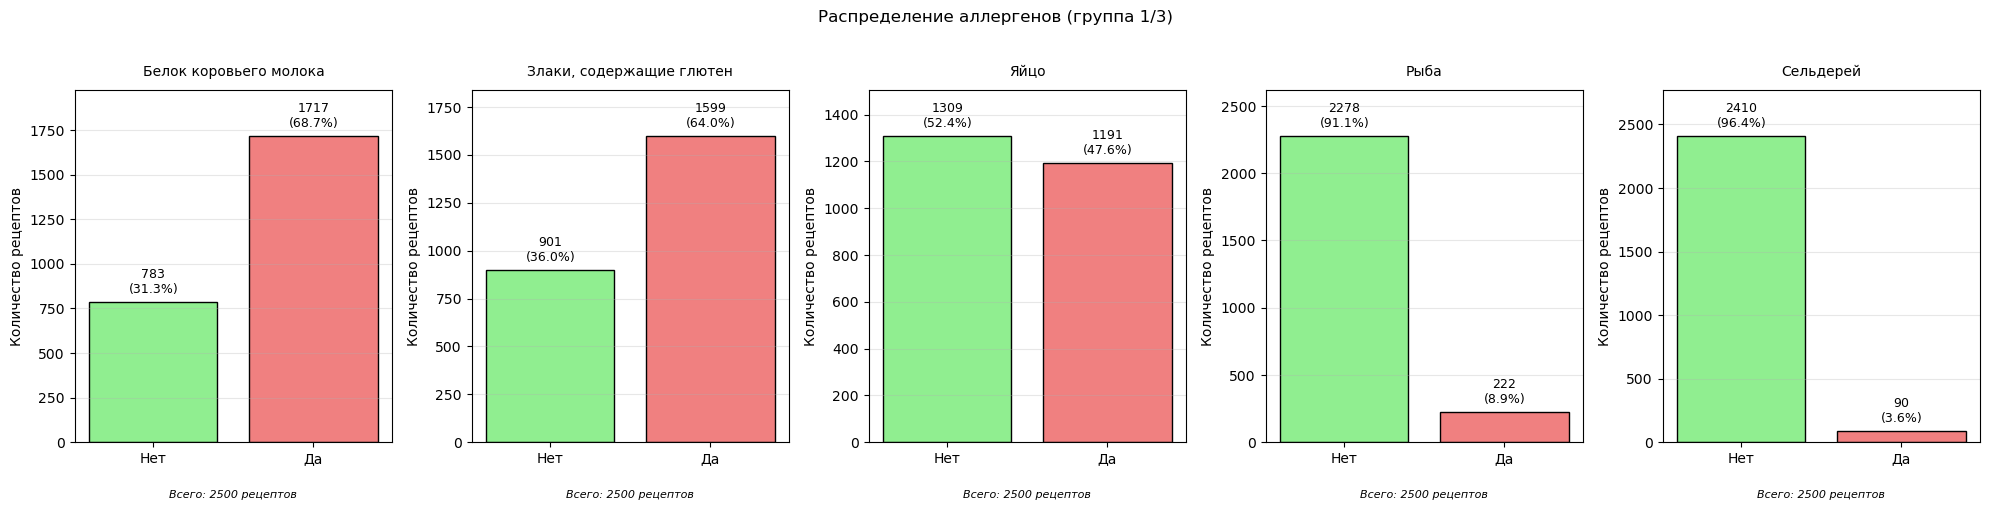

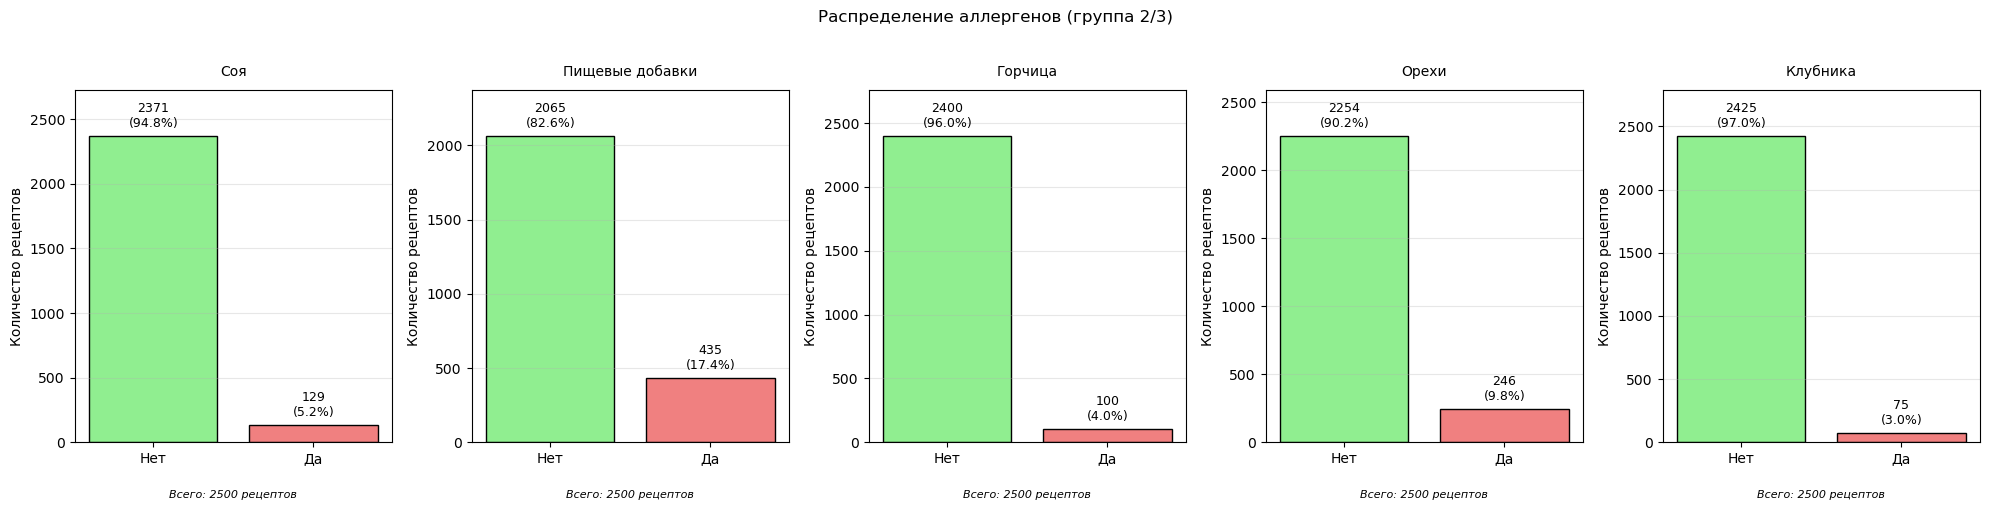

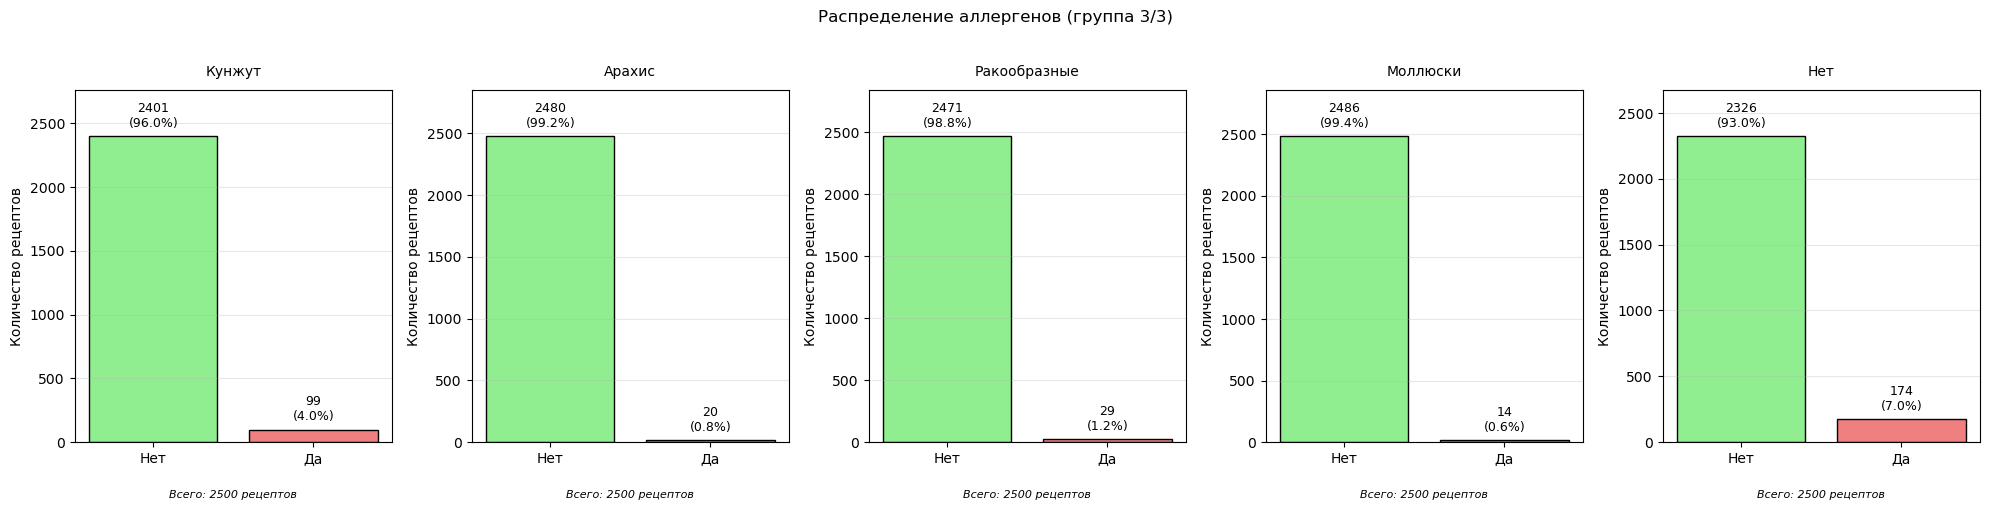


СТАТИСТИКА ПО АЛЛЕРГЕНАМ

Топ аллергенов по частоте встречаемости:
+--------------------------+------------------------+------------------+----------------+-----------------+------------+
| Аллерген                 | Столбец                |   Всего рецептов |   С аллергеном |   Без аллергена | Доля (%)   |
+==========================+========================+==================+================+=================+============+
| Белок коровьего молока   | Белок коровьего молока |             2500 |           1717 |             783 | 68.7%      |
+--------------------------+------------------------+------------------+----------------+-----------------+------------+
| Злаки, содержащие глютен | Злаки                  |             2500 |           1599 |             901 | 64.0%      |
+--------------------------+------------------------+------------------+----------------+-----------------+------------+
| Яйцо                     | Яйцо                   |             2500 |           11

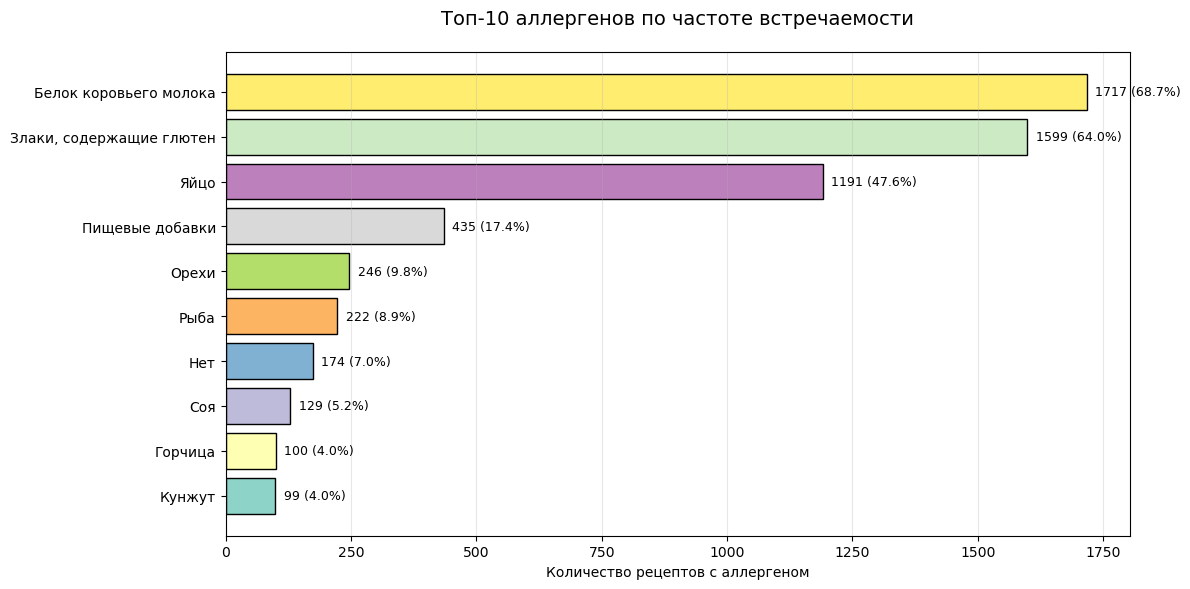

In [63]:
print("\n" + "="*60)
print("3. АНАЛИЗ РАСПРЕДЕЛЕНИЯ АЛЛЕРГЕНОВ")
print("="*60)

# Список аллергенов для анализа
allergens_to_analyze = [
    'Белок коровьего молока',
    'Злаки, содержащие глютен',
    'Яйцо',
    'Рыба',
    'Сельдерей',
    'Соя',
    'Пищевые добавки',
    'Горчица',
    'Орехи',
    'Клубника',
    'Кунжут',
    'Арахис',
    'Ракообразные',
    'Моллюски',
    'Нет'
]

# Проверяем, какие аллергены есть в данных
available_allergens = []
for allergen in allergens_to_analyze:
    # Ищем столбец с этим аллергеном
    for col in data.columns:
        if allergen.lower() in col.lower() or col.lower() in allergen.lower():
            available_allergens.append((allergen, col))
            break

print(f"Найдено {len(available_allergens)} аллергенов из {len(allergens_to_analyze)}")
print("Аллергены для анализа:", [a[0] for a in available_allergens])

# Разбиваем на группы по 5 для визуализации
group_size = 5
num_groups = (len(available_allergens) + group_size - 1) // group_size

for group_num in range(num_groups):
    start_idx = group_num * group_size
    end_idx = min((group_num + 1) * group_size, len(available_allergens))
    group_allergens = available_allergens[start_idx:end_idx]
    
    # Создаем подграфики
    fig, axes = plt.subplots(1, len(group_allergens), figsize=(4*len(group_allergens), 5))
    
    # Если только один подграфик, axes не будет массивом
    if len(group_allergens) == 1:
        axes = [axes]
    
    for idx, (allergen_name, col_name) in enumerate(group_allergens):
        ax = axes[idx]
        
        # Получаем данные для этого аллергена
        if col_name in data.columns:
            allergen_data = data[col_name]
            
            # Считаем распределение
            counts = allergen_data.value_counts()
            total = len(allergen_data)
            
            # Создаем гистограмму (на самом деле барплот)
            bars = ax.bar(['Нет', 'Да'], 
                         [counts.get(0, 0), counts.get(1, 0)],
                         color=['lightgreen', 'lightcoral'],
                         edgecolor='black')
            
            # Добавляем значения на столбцы
            for bar, count in zip(bars, [counts.get(0, 0), counts.get(1, 0)]):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + max(counts.values)*0.02,
                       f'{count}\n({count/total*100:.1f}%)',
                       ha='center', va='bottom', fontsize=9)
            
            # Настройки графика
            ax.set_title(f'{allergen_name}', fontsize=10, pad=10)
            ax.set_ylabel('Количество рецептов')
            ax.set_ylim(0, max(counts.values) * 1.15)
            ax.grid(True, alpha=0.3, axis='y')
            
            # Добавляем общее количество
            ax.text(0.5, -0.15, f'Всего: {total} рецептов',
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=8, style='italic')
        else:
            ax.text(0.5, 0.5, f'Столбец не найден\n"{col_name}"',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(allergen_name, fontsize=10)
    
    plt.suptitle(f'Распределение аллергенов (группа {group_num + 1}/{num_groups})', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Общая статистика по всем аллергенам
print("\n" + "="*60)
print("СТАТИСТИКА ПО АЛЛЕРГЕНАМ")
print("="*60)

# Создаем DataFrame со статистикой
allergen_stats = []

for allergen_name, col_name in available_allergens:
    if col_name in data.columns:
        allergen_data = data[col_name]
        total = len(allergen_data)
        count_with = allergen_data.sum() if allergen_data.dtype in ['int64', 'float64'] else 0
        percentage = (count_with / total * 100) if total > 0 else 0
        
        allergen_stats.append({
            'Аллерген': allergen_name,
            'Столбец': col_name,
            'Всего рецептов': total,
            'С аллергеном': int(count_with),
            'Без аллергена': int(total - count_with),
            'Доля (%)': f'{percentage:.1f}%'
        })

# Сортируем по убыванию частоты
allergen_stats_df = pd.DataFrame(allergen_stats)
if not allergen_stats_df.empty:
    allergen_stats_df = allergen_stats_df.sort_values('С аллергеном', ascending=False)
    
    # Выводим таблицу
    print("\nТоп аллергенов по частоте встречаемости:")
    print(tabulate(allergen_stats_df.head(10), headers='keys', tablefmt='grid', showindex=False))
    
    # Общая сводка
    print(f"\nВсего уникальных аллергенов проанализировано: {len(allergen_stats_df)}")
    print(f"Средняя доля рецептов с аллергенами: {allergen_stats_df['Доля (%)'].str.replace('%', '').astype(float).mean():.1f}%")
    
    # Самые частые аллергены
    print("\nСамые распространенные аллергены:")
    for idx, row in allergen_stats_df.head(5).iterrows():
        print(f"  {row['Аллерген']}: {row['С аллергеном']} рецептов ({row['Доля (%)']})")
    
    # Самые редкие аллергены
    print("\nСамые редкие аллергены:")
    for idx, row in allergen_stats_df.tail(5).iterrows():
        print(f"  {row['Аллерген']}: {row['С аллергеном']} рецептов ({row['Доля (%)']})")
else:
    print("Нет данных по аллергенам для анализа")

# Дополнительная визуализация: топ-10 аллергенов
if len(allergen_stats_df) > 0:
    print("\n" + "="*60)
    print("ТОП-10 АЛЛЕРГЕНОВ ПО ЧАСТОТЕ")
    print("="*60)
    
    # Берем топ-10
    top_10 = allergen_stats_df.head(10).copy()
    top_10 = top_10.sort_values('С аллергеном', ascending=True)  # Сортируем для горизонтального графика
    
    # Создаем горизонтальный барплот
    plt.figure(figsize=(12, 6))
    
    # Используем цветовую карту
    colors = plt.cm.Set3(np.linspace(0, 1, len(top_10)))
    
    bars = plt.barh(top_10['Аллерген'], top_10['С аллергеном'], color=colors, edgecolor='black')
    
    # Добавляем значения
    for bar, count, pct in zip(bars, top_10['С аллергеном'], top_10['Доля (%)']):
        plt.text(bar.get_width() + max(top_10['С аллергеном']) * 0.01, 
                bar.get_y() + bar.get_height()/2,
                f'{count} ({pct})',
                va='center', fontsize=9)
    
    plt.xlabel('Количество рецептов с аллергеном')
    plt.title('Топ-10 аллергенов по частоте встречаемости', fontsize=14, pad=20)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

Не так уж мало рецептов с белком коровьего молока - почти 70%

### Переведем время в минуты

In [45]:
def time_to_minutes(time_str):
    """
    Конвертирует строку времени в минуты.
    Обрабатывает: '55 минут', '2 часа 30 минут', '1 час', '9 часов 10 минут'
    """
    if pd.isna(time_str):
        return np.nan
    
    time_str = str(time_str).lower().strip()
    
    # Инициализируем переменные
    hours = 0
    minutes = 0
    
    # Обрабатываем часы
    if 'час' in time_str:
        # Находим часть с часами
        hour_part = time_str.split('час')[0].strip()
        
        # Извлекаем число часов (может быть "9", "1", "2" и т.д.)
        # Ищем числа в строке
        # import re 
        hour_match = re.search(r'\d+', hour_part)
        if hour_match:
            hours = int(hour_match.group())
    
    # Обрабатываем минуты
    if 'минут' in time_str:
        # Находим часть с минутами (после 'час' или всю строку если нет часов)
        if 'час' in time_str:
            minute_part = time_str.split('час')[1]
        else:
            minute_part = time_str
        
        # Извлекаем число минут
        minute_match = re.search(r'\d+', minute_part)
        if minute_match:
            minutes = int(minute_match.group())
    
    # Если нет ни часов, ни минут, но есть просто число (например "55")
    elif re.search(r'^\d+$', time_str):
        minutes = int(time_str)
    
    return hours * 60 + minutes

# Применяем функцию
data['ready_in_minutes'] = data['ready_in'].apply(time_to_minutes)
data['kitchen_time_in_minutes'] = data['kitchen_time'].apply(time_to_minutes)

In [46]:
data.head(2)

,id,url,page,title,description,dish_image,kbju,ready_in,kitchen_time,cuisine,common_allergens,ingredients,recipe,calories,protein,fat,carbs,calorie_category,Белок коровьего молока,Злаки,содержащие глютен,Яйцо,Рыба,Сельдерей,Соя,Пищевые добавки,Горчица,Орехи,Клубника,Нет,Кунжут,Арахис,Ракообразные,Моллюски,ready_in_minutes,kitchen_time_in_minutes
0,267099,https://food.ru/recipes/267099-zakusochnye-kek...,1,Закусочные кексы из замороженных овощей,Тесто для этих кексов не нужно долго замешиват...,https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 118.19, 'protein': 6.51, 'fat': 4...",55 минут,20 минут,европейская,"[Белок коровьего молока, Злаки, содержащие глю...","[Замороженная смесь «8 овощей» 400 г, Кефир 2,...",### подготовиться\n![подготовиться](https://cd...,118.19,6.51,4.24,13.10,Очень низкая,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,55,20
1,267097,https://food.ru/recipes/267097-tosty-s-konserv...,1,Сэндвичи с консервированым лососем,"В этом рецепте объединились и европейские, и а...",https://cdn.food.ru/unsigned/fit/640/480/ce/0/...,"{'calories': 203.11, 'protein': 10.37, 'fat': ...",15 минут,15 минут,европейская,"[Злаки, содержащие глютен, Рыба, Сельдерей, Со...","[Хлеб цельнозерновой 200 г, Майонез 3 ст. л. =...",### подготовиться\n![подготовиться](https://cd...,203.11,10.37,12.41,11.59,Низкая,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,15,15



4. АНАЛИЗ ВРЕМЕНИ ПРИГОТОВЛЕНИЯ


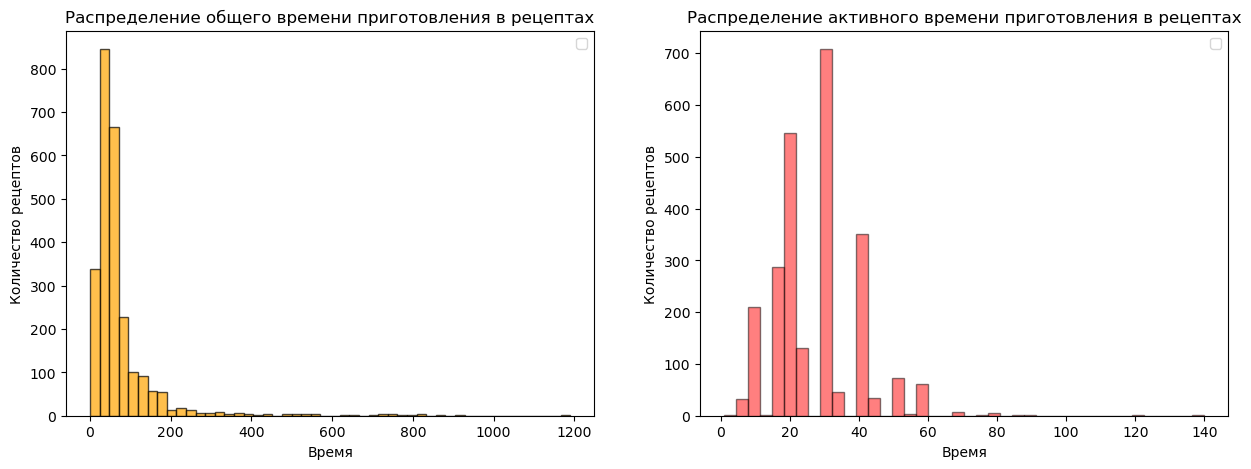


СТАТИСТИКА ВРЕМЕНИ ПРИГОТОВЛЕНИЯ:
----------------------------------------
Общее время приготовления:
  Мин: 0 мин
  Макс: 1190 мин
  Среднее: 72.9 мин
  Медиана: 50.0 мин
  Std: 93.7 мин
  Количество NaN: 0

Активное время приготовления:
  Мин: 1 мин
  Макс: 140 мин
  Среднее: 27.2 мин
  Медиана: 30.0 мин
  Std: 12.5 мин
  Количество NaN: 0


In [55]:
print("\n" + "="*50)
print("4. АНАЛИЗ ВРЕМЕНИ ПРИГОТОВЛЕНИЯ")
print("="*50)

# Гистограмма распределения калорий
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Распределение калорий
axes[0].hist(data['ready_in_minutes'].dropna(), bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Количество рецептов')
axes[0].set_title('Распределение общего времени приготовления в рецептах')
# axes[0,0].axvline(data['ready_in_minutes'].median(), color='red', linestyle='--', 
#                   label=f'Медиана: {data["ready_in_minutes"].median():.1f}')
# axes[0,0].axvline(data['ready_in_minutes'].mean(), color='green', linestyle='--', 
#                   label=f'Среднее: {data["ready_in_minutes"].mean():.1f}')
axes[0].legend()

# Распределение белков
axes[1].hist(data['kitchen_time_in_minutes'].dropna(), bins=40, edgecolor='black', color='red', alpha=0.5)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Количество рецептов')
axes[1].set_title('Распределение активного времени приготовления в рецептах')
# axes[0,1].axvline(data['protein'].median(), color='red', linestyle='--', 
#                   label=f'Медиана: {data["protein"].median():.1f}')
# axes[0,1].axvline(data['protein'].mean(), color='green', linestyle='--', 
#                   label=f'Среднее: {data["protein"].mean():.1f}')
axes[1].legend()  
plt.show()

# Выводим статистику
print("\nСТАТИСТИКА ВРЕМЕНИ ПРИГОТОВЛЕНИЯ:")
print("-" * 40)

if 'ready_in_minutes' in data.columns and data['ready_in_minutes'].notna().any():
    print("Общее время приготовления:")
    print(f"  Мин: {data['ready_in_minutes'].min():.0f} мин")
    print(f"  Макс: {data['ready_in_minutes'].max():.0f} мин")
    print(f"  Среднее: {data['ready_in_minutes'].mean():.1f} мин")
    print(f"  Медиана: {data['ready_in_minutes'].median():.1f} мин")
    print(f"  Std: {data['ready_in_minutes'].std():.1f} мин")
    print(f"  Количество NaN: {data['ready_in_minutes'].isna().sum()}")
else:
    print("Нет данных по общему времени приготовления")

print()

if 'kitchen_time_in_minutes' in data.columns and data['kitchen_time_in_minutes'].notna().any():
    print("Активное время приготовления:")
    print(f"  Мин: {data['kitchen_time_in_minutes'].min():.0f} мин")
    print(f"  Макс: {data['kitchen_time_in_minutes'].max():.0f} мин")
    print(f"  Среднее: {data['kitchen_time_in_minutes'].mean():.1f} мин")
    print(f"  Медиана: {data['kitchen_time_in_minutes'].median():.1f} мин")
    print(f"  Std: {data['kitchen_time_in_minutes'].std():.1f} мин")
    print(f"  Количество NaN: {data['kitchen_time_in_minutes'].isna().sum()}")
else:
    print("Нет данных по активному времени приготовления")

В результате EDA удалось убедиться, что данные представлены для всех необходимых паттернов (есть рецепты и для перекусов низкокаллорийных, и для полноценных блюд, требующих долгого приготовления). Также достаточно данных по аллергенам (выделено 16 основных категорий). Пропусков и дублей в данных нет.    
Также было проведена обработка данных, добавлены новые столбцы, преобразованы старые.

## Сгенерируем датафрейм для пользователя

Нагенерируем данных для пользователей   
Сделаем их не очень много, но реалистичными, чтобы было под что оптимизировать модель

Генерация данных пользователей...
Сгенерировано 1000 пользователей

Структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    1000 non-null   int64  
 1   возраст                    1000 non-null   int64  
 2   пол                        1000 non-null   object 
 3   рост_см                    1000 non-null   int64  
 4   вес_кг                     1000 non-null   float64
 5   категория_времени_готовки  1000 non-null   object 
 6   уровень_активности         1000 non-null   object 
 7   цель_питания               1000 non-null   object 
 8   Белок коровьего молока     1000 non-null   int64  
 9   Злаки, содержащие глютен   1000 non-null   int64  
 10  Яйцо                       1000 non-null   int64  
 11  Рыба                       1000 non-null   int64  
 12  Сельдерей          


Сохранить данные в CSV файл? (да/нет):  да


Данные сохранены в файл: user_data_20251215_164710.csv


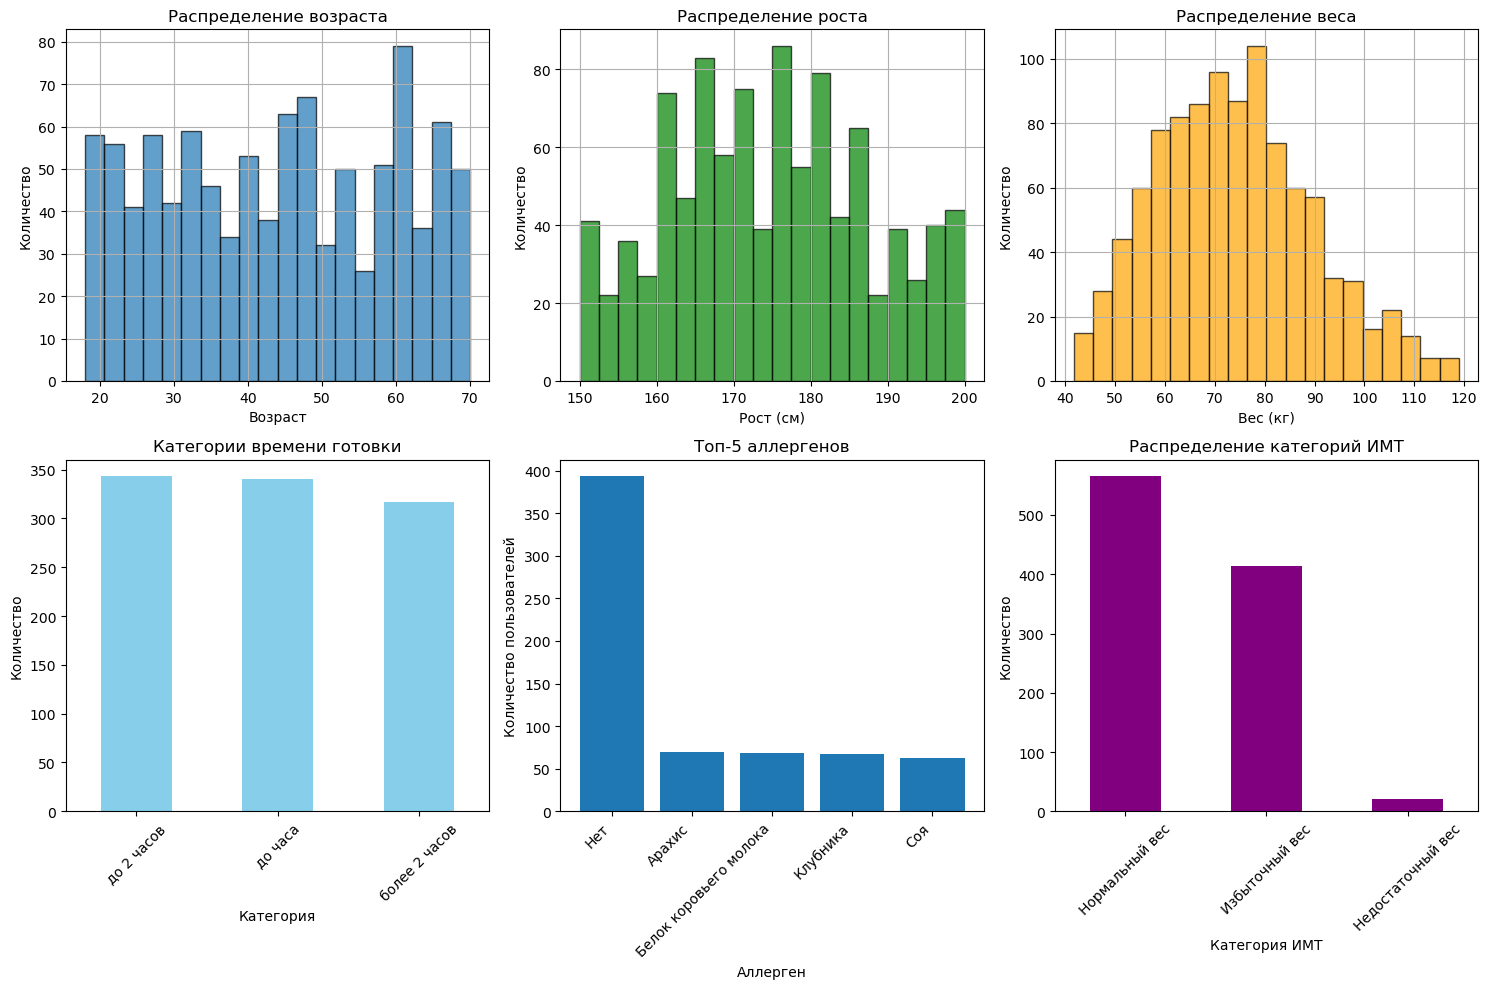


Создать профиль пользователя вручную? (да/нет):  нет


In [66]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime

# Инициализируем Faker для генерации реалистичных данных
fake = Faker('ru_RU')  # Русская локализация

def generate_user_data(num_users=5000):
    """
    Генерирует данные пользователей
    
    Параметры:
    num_users (int): количество пользователей для генерации
    """
    
    # Список аллергенов
    allergens = [
        'Белок коровьего молока',
        'Злаки, содержащие глютен',
        'Яйцо',
        'Рыба',
        'Сельдерей',
        'Соя',
        'Пищевые добавки',
        'Горчица',
        'Орехи',
        'Клубника',
        'Нет',
        'Кунжут',
        'Арахис',
        'Ракообразные',
        'Моллюски'
    ]
    
    # Категории времени готовки
    cooking_time_categories = ['до часа', 'до 2 часов', 'более 2 часов']
    
    # Создаем список для хранения данных
    users_data = []
    
    for user_id in range(1, num_users + 1):
        # Генерация возраста (18-70 лет)
        age = random.randint(18, 70)
        
        # Генерация пола
        gender = random.choice(['Мужской', 'Женский'])
        
        # Генерация роста с учетом пола
        if gender == 'Мужской':
            height = random.randint(160, 200)  # рост мужчин
        else:
            height = random.randint(150, 185)  # рост женщин
        
        # Генерация веса с учетом роста и пола
        # Используем формулу ИМТ для реалистичности
        if gender == 'Мужской':
            bmi = random.uniform(20, 30)  # ИМТ от 20 до 30
        else:
            bmi = random.uniform(18, 28)  # ИМТ от 18 до 28
        
        weight = round(bmi * (height/100)**2, 1)
        
        # Генерация аллергенов
        # Вероятность иметь аллергии
        has_allergies = random.choices([True, False], weights=[0.6, 0.4])[0]
        
        allergen_flags = {}
        for allergen in allergens:
            if allergen == 'Нет':
                # Если нет аллергий, ставим 1, иначе 0
                allergen_flags[allergen] = 1 if not has_allergies else 0
            else:
                # Для остальных аллергенов
                if has_allergies:
                    # Вероятность наличия конкретной аллергии
                    prob = random.choices([0, 1], weights=[0.9, 0.1])[0]
                    allergen_flags[allergen] = prob
                else:
                    allergen_flags[allergen] = 0
        
        # Если выбраны другие аллергены, то 'Нет' должен быть 0
        if has_allergies and sum([allergen_flags[a] for a in allergens if a != 'Нет']) > 0:
            allergen_flags['Нет'] = 0
        
        # Генерация категории времени готовки
        cooking_time = random.choice(cooking_time_categories)
        
        # Дополнительная информация
        activity_level = random.choice(['Низкий', 'Умеренный', 'Высокий', 'Очень высокий'])
        
        # Цели питания
        diet_goals = random.choices(
            ['Похудение', 'Поддержание веса', 'Набор мышечной массы', 'Здоровое питание'],
            weights=[0.3, 0.4, 0.2, 0.1]
        )[0]
        
        # Создаем запись пользователя
        user_record = {
            'user_id': user_id,
            'возраст': age,
            'пол': gender,
            'рост_см': height,
            'вес_кг': weight,
            'категория_времени_готовки': cooking_time,
            'уровень_активности': activity_level,
            'цель_питания': diet_goals,
        }
        
        # Добавляем флаги аллергенов
        user_record.update(allergen_flags)
        
        users_data.append(user_record)
    
    # Создаем DataFrame
    df_users = pd.DataFrame(users_data)
    
    return df_users

# Генерация данных пользователей
print("Генерация данных пользователей...")
users_df = generate_user_data(num_users=1000)

# Выводим информацию о данных
print(f"Сгенерировано {len(users_df)} пользователей")
print(f"\nСтруктура данных:")
print(users_df.info())

print("\nПервые 5 пользователей:")
print(users_df.head())

print("\nСтатистика по числовым признакам:")
print(users_df[['возраст', 'рост_см', 'вес_кг']].describe())

# Статистика по категориальным признакам
print("\nРаспределение по полу:")
print(users_df['пол'].value_counts())

print("\nРаспределение по категориям времени готовки:")
print(users_df['категория_времени_готовки'].value_counts())

print("\nРаспределение по уровню активности:")
print(users_df['уровень_активности'].value_counts())

print("\nРаспределение по целям питания:")
print(users_df['цель_питания'].value_counts())

# Статистика по аллергенам
allergen_columns = [
    'Белок коровьего молока',
    'Злаки, содержащие глютен',
    'Яйцо',
    'Рыба',
    'Сельдерей',
    'Соя',
    'Пищевые добавки',
    'Горчица',
    'Орехи',
    'Клубника',
    'Нет',
    'Кунжут',
    'Арахис',
    'Ракообразные',
    'Моллюски'
]

print("\nСтатистика по аллергенам:")
allergen_stats = []
for allergen in allergen_columns:
    count = users_df[allergen].sum()
    percentage = (count / len(users_df)) * 100
    allergen_stats.append({
        'Аллерген': allergen,
        'Количество пользователей': int(count),
        'Доля (%)': f'{percentage:.1f}%'
    })

allergen_stats_df = pd.DataFrame(allergen_stats).sort_values('Количество пользователей', ascending=False)
print(allergen_stats_df.to_string(index=False))

# Расчет ИМТ для проверки реалистичности
print("\nСтатистика по ИМТ:")
users_df['ИМТ'] = users_df['вес_кг'] / ((users_df['рост_см'] / 100) ** 2)
print(users_df['ИМТ'].describe())

# Категории ИМТ
def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Недостаточный вес'
    elif bmi < 25:
        return 'Нормальный вес'
    elif bmi < 30:
        return 'Избыточный вес'
    else:
        return 'Ожирение'

users_df['категория_ИМТ'] = users_df['ИМТ'].apply(get_bmi_category)
print("\nРаспределение по категориям ИМТ:")
print(users_df['категория_ИМТ'].value_counts())

# Сохранение в файл (опционально)
save_to_file = input("\nСохранить данные в CSV файл? (да/нет): ").lower()
if save_to_file in ['да', 'yes', 'y', 'д']:
    filename = f"user_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    users_df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"Данные сохранены в файл: {filename}")

# Визуализация (дополнительно)
import matplotlib.pyplot as plt

# Настройка графиков
plt.figure(figsize=(15, 10))

# 1. Распределение возраста
plt.subplot(2, 3, 1)
users_df['возраст'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')

# 2. Распределение роста
plt.subplot(2, 3, 2)
users_df['рост_см'].hist(bins=20, edgecolor='black', alpha=0.7, color='green')
plt.title('Распределение роста')
plt.xlabel('Рост (см)')
plt.ylabel('Количество')

# 3. Распределение веса
plt.subplot(2, 3, 3)
users_df['вес_кг'].hist(bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.title('Распределение веса')
plt.xlabel('Вес (кг)')
plt.ylabel('Количество')

# 4. Категории времени готовки
plt.subplot(2, 3, 4)
users_df['категория_времени_готовки'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Категории времени готовки')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)

# 5. Топ-5 аллергенов
plt.subplot(2, 3, 5)
top_5_allergens = allergen_stats_df.head(5)
plt.bar(top_5_allergens['Аллерген'], top_5_allergens['Количество пользователей'].astype(int))
plt.title('Топ-5 аллергенов')
plt.xlabel('Аллерген')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45, ha='right')

# 6. Распределение ИМТ
plt.subplot(2, 3, 6)
users_df['категория_ИМТ'].value_counts().plot(kind='bar', color='purple')
plt.title('Распределение категорий ИМТ')
plt.xlabel('Категория ИМТ')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Создание профиля нового пользователя (пример)
def create_single_user_profile():
    """Создает профиль одного пользователя для тестирования"""
    
    allergens = [
        'Белок коровьего молока',
        'Злаки, содержащие глютен',
        'Яйцо',
        'Рыба',
        'Сельдерей',
        'Соя',
        'Пищевые добавки',
        'Горчица',
        'Орехи',
        'Клубника',
        'Нет',
        'Кунжут',
        'Арахис',
        'Ракообразные',
        'Моллюски'
    ]
    
    cooking_time_categories = ['до часа', 'до 2 часов', 'более 2 часов']
    
    print("\n" + "="*50)
    print("СОЗДАНИЕ ПРОФИЛЯ ПОЛЬЗОВАТЕЛЯ")
    print("="*50)
    
    # Ввод данных пользователем
    print("\nВведите данные пользователя:")
    
    age = int(input("Возраст: "))
    gender = input("Пол (Мужской/Женский): ")
    height = int(input("Рост (см): "))
    weight = float(input("Вес (кг): "))
    
    print("\nВыберите категорию времени готовки:")
    for i, category in enumerate(cooking_time_categories, 1):
        print(f"{i}. {category}")
    cooking_choice = int(input("Ваш выбор (1-3): "))
    cooking_time = cooking_time_categories[cooking_choice-1]
    
    print("\nВыберите аллергены (введите номера через запятую):")
    for i, allergen in enumerate(allergens, 1):
        print(f"{i:2}. {allergen}")
    
    allergen_choices = input("Ваш выбор: ").split(',')
    allergen_indices = [int(choice.strip()) - 1 for choice in allergen_choices if choice.strip().isdigit()]
    
    # Создаем профиль
    user_profile = {
        'user_id': 'custom_user',
        'возраст': age,
        'пол': gender,
        'рост_см': height,
        'вес_кг': weight,
        'категория_времени_готовки': cooking_time,
        'уровень_активности': 'Умеренный',  # можно добавить выбор
        'цель_питания': 'Здоровое питание',  # можно добавить выбор
    }
    
    # Добавляем аллергены
    for i, allergen in enumerate(allergens):
        user_profile[allergen] = 1 if i in allergen_indices else 0
    
    return pd.DataFrame([user_profile])

# Пример создания профиля одного пользователя
create_profile = input("\nСоздать профиль пользователя вручную? (да/нет): ").lower()
if create_profile in ['да', 'yes', 'y', 'д']:
    user_profile_df = create_single_user_profile()
    print("\nСозданный профиль пользователя:")
    print(user_profile_df.T)  # Транспонируем для лучшего отображения

Все распределения выглядят правдоподобно, на первых этапах планируется использовать данные для фильтров рецептов, далее данные заменим на реальные